# Model Training and Analysis

This notebook prepares deep-learning experiments for image watermarking, runs training on a small subset and the full dataset, and compares their results.

In [1]:
import os
import sys
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.data import get_dataloaders
from src.train import TrainConfig, fit, run_training
from src.utils import SEED

In [2]:
DATA_DIR = Path("../data")
SPLITS_FILE = DATA_DIR / "splits.json"

## Helper Functions

We will first define functions for preparing a smaller split and for loading, summarizing and visualizing the results.

In [3]:
def make_subset_splits_file(source_splits_file, output_splits_file, n_train=16, n_val=4, n_test=4):
    """Create a small split with the first `n` images of each split from an existing one."""

    with open(source_splits_file, "r") as f:
        splits = json.load(f)

    subset = {
        "train": splits["train"][:n_train],
        "val": splits["val"][:n_val],
        "test": splits["test"][:n_test],
    }

    output_splits_file = Path(output_splits_file)
    output_splits_file.parent.mkdir(parents=True, exist_ok=True)
    with output_splits_file.open("w") as f:
        json.dump(subset, f, indent=2)

    return output_splits_file

In [4]:
def clear_training_log(log_path):
    """Remove an old log before starting a fresh experiment."""

    log_path = Path(log_path)
    if log_path.exists():
        log_path.unlink()


def load_training_log(log_path):
    """Load a log file written by training function into a pandas DataFrame."""

    log_path = Path(log_path)
    if not log_path.exists():
        raise FileNotFoundError(f"No log file found at {log_path}")

    return pd.read_csv(log_path)


def summarize_training_log(df, name="", show_validation=True):
    """Print the best and last epoch statistics."""

    selection_metric = "val_loss" if show_validation else "train_loss"
    best_row = df.loc[df[selection_metric].idxmin()]
    last_row = df.iloc[-1]

    title = f"Summary for {name}" if name else "Summary"
    print(title)
    print("-" * len(title))
    print(f"Epochs run: {int(last_row['epoch'])}")
    print(
        f"Best result by {selection_metric}: "
        f"epoch {int(best_row['epoch'])}"
    )
    print(
        f"  train: loss={best_row['train_loss']:.4f}, "
        f"BER={best_row['train_ber']:.4f}, "
        f"exact_accuracy={best_row['train_exact_accuracy']:.4f}, "
        f"PSNR={best_row['train_psnr']:.2f}"
    )
    if show_validation:
        print(
            f"  val: loss={best_row['val_loss']:.4f}, "
            f"BER={best_row['val_ber']:.4f}, "
            f"exact_accuracy={best_row['val_exact_accuracy']:.4f}, "
            f"PSNR={best_row['val_psnr']:.2f}"
        )
    print("Last epoch:")
    print(
        f"  train: loss={last_row['train_loss']:.4f}, "
        f"BER={last_row['train_ber']:.4f}, "
        f"exact_accuracy={last_row['train_exact_accuracy']:.4f}, "
        f"PSNR={last_row['train_psnr']:.2f}"
    )
    if show_validation:
        print(
            f"  val: loss={last_row['val_loss']:.4f}, "
            f"BER={last_row['val_ber']:.4f}, "
            f"exact_accuracy={last_row['val_exact_accuracy']:.4f}, "
            f"PSNR={last_row['val_psnr']:.2f}"
        )

    return best_row, last_row


def plot_training_log(
    df,
    name="",
    metrics=("loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"),
    show_validation=True,
):
    """Plot metric curves from a training log."""

    metrics = [m for m in metrics if f"train_{m}" in df.columns or f"val_{m}" in df.columns]
    n_cols = 3
    n_rows = -(-len(metrics) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for i, metric in enumerate(metrics):
        ax = axes[i // n_cols][i % n_cols]
        if f"train_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"train_{metric}"], label="train")
        if show_validation and f"val_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"val_{metric}"], label="val")
        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()

    for j in range(len(metrics), n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis("off")

    fig.suptitle(name)
    fig.tight_layout()
    plt.show()


def analyze_run(log_path, name="", show_validation=True):
    """Load, summarize and plot a training run log file."""

    df = load_training_log(log_path)
    summarize_training_log(
        df,
        name=name,
        show_validation=show_validation,
    )
    plot_training_log(
        df,
        name=name,
        show_validation=show_validation,
    )
    return df

## Tiny-Set Overfitting Check

We train on eight images with fixed messages and no image-quality penalty. The goal is to verify that the encoder-decoder pipeline can fully memorize a small training set before running full-dataset experiments.

In [5]:
SMALL_SPLIT_FILE = make_subset_splits_file(
    SPLITS_FILE,
    DATA_DIR / "splits_small.json",
    n_train=8,
    n_val=0,
    n_test=0,
)
SMALL_SPLIT_FILE

WindowsPath('../data/splits_small.json')

Epoch 1/250 | train_loss=0.7158 | train_BER=0.5234 | train_exact=0.0000 | 1.0s


Epoch 25/250 | train_loss=0.5288 | train_BER=0.1797 | train_exact=0.0000 | 0.2s


Epoch 50/250 | train_loss=0.4495 | train_BER=0.0938 | train_exact=0.1250 | 0.2s


Epoch 75/250 | train_loss=0.3817 | train_BER=0.0625 | train_exact=0.5000 | 0.2s


Epoch 100/250 | train_loss=0.3252 | train_BER=0.0391 | train_exact=0.6250 | 0.3s


...

Epoch 150/250 | train_loss=0.2307 | train_BER=0.0156 | train_exact=0.7500 | 0.3s


Epoch 175/250 | train_loss=0.1954 | train_BER=0.0000 | train_exact=1.0000 | 0.3s


Epoch 200/250 | train_loss=0.1659 | train_BER=0.0000 | train_exact=1.0000 | 0.3s


Epoch 225/250 | train_loss=0.1415 | train_BER=0.0000 | train_exact=1.0000 | 0.3s


Epoch 250/250 | train_loss=0.1214 | train_BER=0.0000 | train_exact=1.0000 | 0.3s
Training time: 1.2 minutes
Summary for Different architecture tiny overfit
-----------------------------------------------
Epochs run: 250
Best result by train_loss: epoch 250
  train: loss=0.1214, BER=0.0000, exact_accuracy=1.0000, PSNR=33.21
Last epoch:
  train: loss=0.1214, BER=0.0000, exact_accuracy=1.0000, PSNR=33.21


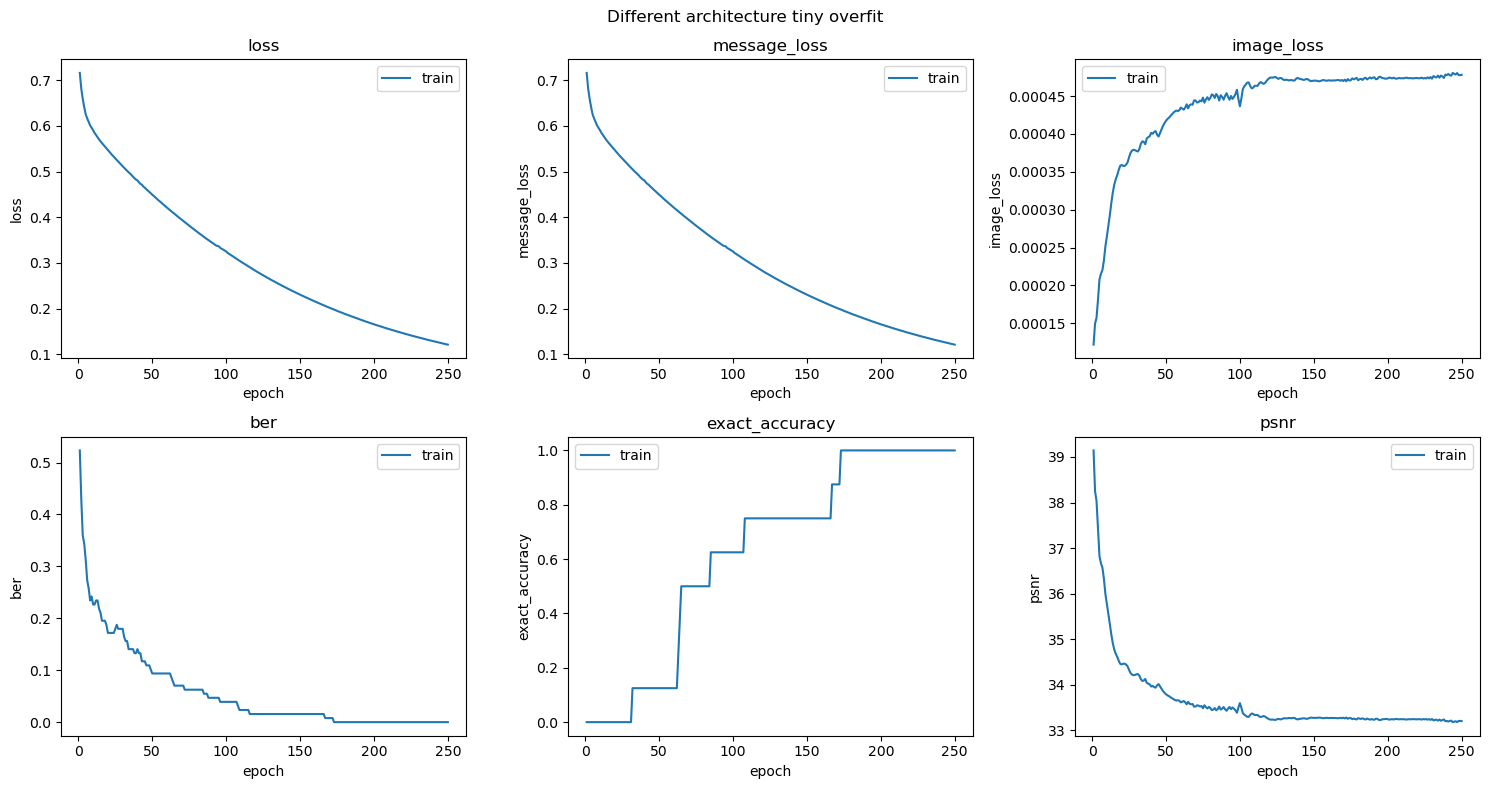

In [6]:
tiny_config = TrainConfig(
    experiment_name="different-architecture-tiny",
    epochs=250,
    batch_size=8,
    message_length=16,
    encoder_channels=40,
    decoder_channels=40,
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/different-architecture-tiny.csv",
    attack_configs=None,
    print_every=25,
)

clear_training_log(tiny_config.log_path)

with open(SMALL_SPLIT_FILE, "r") as f:
    n_train_images = len(json.load(f)["train"])

tiny_messages = torch.randint(
    0,
    2,
    (n_train_images, tiny_config.message_length),
    generator=torch.Generator().manual_seed(SEED),
    dtype=torch.float32,
)

tiny_train_loader, _, _ = get_dataloaders(
    DATA_DIR,
    SMALL_SPLIT_FILE,
    batch_size=tiny_config.batch_size,
    num_workers=0,
    shuffle_train=False,
)

tiny_encoder, tiny_decoder, tiny_history = fit(
    train_loader=tiny_train_loader,
    val_loader=tiny_train_loader,
    config=tiny_config,
    fixed_train_messages=tiny_messages,
    fixed_val_messages=tiny_messages,
)

tiny_df = analyze_run(
    tiny_config.log_path,
    name="Different architecture tiny overfit",
    show_validation=False,
)

### Different Architecture Tiny Result

The 16-bit model reaches training BER `0` and exact message accuracy `1` by epoch 175. At epoch 250, both the training pass and the evaluation-mode pass over the same eight images have BER `0` and exact accuracy `1`; training PSNR is `33.21` dB. The run takes `1.1` minutes.

This passes the tiny-set gate, so we proceed to one larger clean check. The next run uses 1,024 training images and 128 validation images, batch size 16, `max_delta=0.03`, and no noise or image-loss term. We first run 10 epochs and continue the same checkpoint to at most 20 only if validation BER clearly improves. This is a trend check, not final test-set evaluation.

Epoch 1/10 | train_loss=0.6916 | train_BER=0.4752 | train_exact=0.0000 | val_loss=0.6808 | val_BER=0.4473 | val_exact=0.0000 | val_PSNR=33.77 | 29.7s


Epoch 2/10 | train_loss=0.6769 | train_BER=0.4339 | train_exact=0.0010 | val_loss=0.6780 | val_BER=0.4263 | val_exact=0.0000 | val_PSNR=32.43 | 23.3s


Epoch 3/10 | train_loss=0.6720 | train_BER=0.4234 | train_exact=0.0000 | val_loss=0.6727 | val_BER=0.4092 | val_exact=0.0000 | val_PSNR=32.40 | 23.9s


Epoch 4/10 | train_loss=0.6701 | train_BER=0.4241 | train_exact=0.0000 | val_loss=0.6670 | val_BER=0.4082 | val_exact=0.0000 | val_PSNR=32.65 | 23.7s


Epoch 5/10 | train_loss=0.6674 | train_BER=0.4189 | train_exact=0.0000 | val_loss=0.6685 | val_BER=0.4204 | val_exact=0.0000 | val_PSNR=32.50 | 23.8s


Epoch 6/10 | train_loss=0.6621 | train_BER=0.4082 | train_exact=0.0000 | val_loss=0.6613 | val_BER=0.4097 | val_exact=0.0000 | val_PSNR=32.56 | 23.2s


Epoch 7/10 | train_loss=0.6580 | train_BER=0.3958 | train_exact=0.0000 | val_loss=0.6772 | val_BER=0.4150 | val_exact=0.0000 | val_PSNR=32.42 | 22.8s


Epoch 8/10 | train_loss=0.6543 | train_BER=0.3931 | train_exact=0.0000 | val_loss=0.6560 | val_BER=0.3931 | val_exact=0.0000 | val_PSNR=32.29 | 23.5s


Epoch 9/10 | train_loss=0.6563 | train_BER=0.3979 | train_exact=0.0000 | val_loss=0.6560 | val_BER=0.3940 | val_exact=0.0000 | val_PSNR=32.68 | 23.7s


Epoch 10/10 | train_loss=0.6524 | train_BER=0.3885 | train_exact=0.0000 | val_loss=0.6534 | val_BER=0.3896 | val_exact=0.0000 | val_PSNR=32.48 | 23.6s
Training time: 4.0 minutes
Summary for Different architecture medium clean check
-----------------------------------------------------
Epochs run: 10
Best result by val_loss: epoch 10
  train: loss=0.6524, BER=0.3885, exact_accuracy=0.0000, PSNR=32.70
  val: loss=0.6534, BER=0.3896, exact_accuracy=0.0000, PSNR=32.48
Last epoch:
  train: loss=0.6524, BER=0.3885, exact_accuracy=0.0000, PSNR=32.70
  val: loss=0.6534, BER=0.3896, exact_accuracy=0.0000, PSNR=32.48


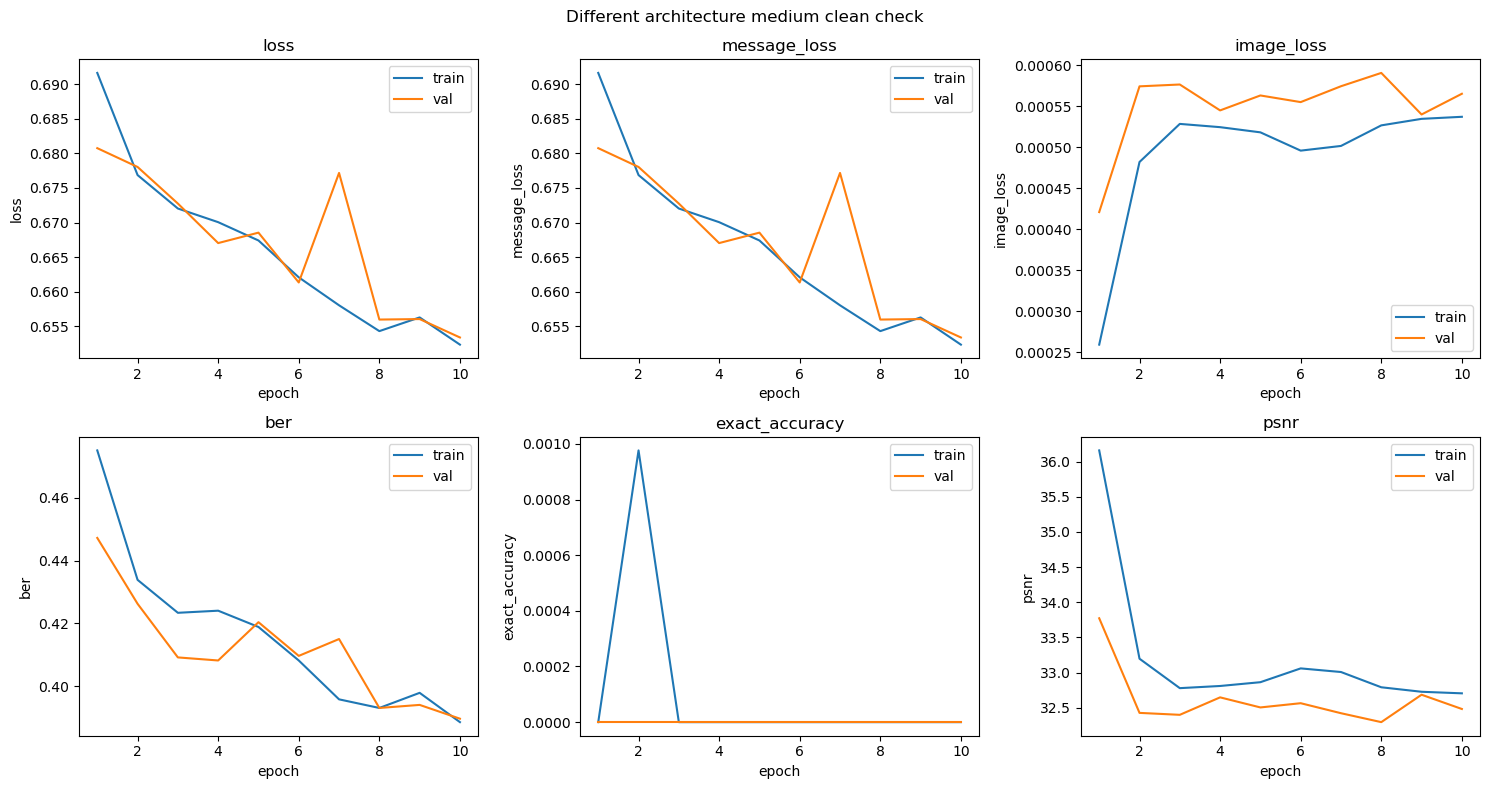

In [7]:
MEDIUM_SPLIT_FILE = make_subset_splits_file(
    SPLITS_FILE,
    Path("../results/splits/different-architecture-medium.json"),
    n_train=1024,
    n_val=128,
    n_test=0,
)

medium_config = TrainConfig(
    experiment_name="different-architecture-medium",
    epochs=10,
    batch_size=16,
    message_length=16,
    encoder_channels=40,
    decoder_channels=40,
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/different-architecture-medium.csv",
    attack_configs=None,
    print_every=1,
)

clear_training_log(medium_config.log_path)

medium_encoder, medium_decoder, medium_history = run_training(
    data_dir=DATA_DIR,
    splits_file=MEDIUM_SPLIT_FILE,
    config=medium_config,
    num_workers=4,
)

medium_df = analyze_run(
    medium_config.log_path,
    name="Different architecture medium clean check",
)

### Continue the Medium Clean Check

The first 10 epochs showed a decreasing validation BER, so the same checkpoint is continued to epoch 20. The table after training reads the complete CSV log, including epochs produced before this notebook cell was added.

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.train import TrainConfig, run_training

medium_config = TrainConfig(
    experiment_name="different-architecture-medium",
    epochs=20,
    batch_size=16,
    message_length=16,
    encoder_channels=40,
    decoder_channels=40,
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir=str(PROJECT_ROOT / "results" / "checkpoints"),
    log_path=str(PROJECT_ROOT / "results" / "logs" / "different-architecture-medium.csv"),
    attack_configs=None,
    print_every=1,
)

medium_checkpoint = (
    Path(medium_config.checkpoint_dir)
    / medium_config.experiment_name
    / "last.pt"
)

medium_encoder, medium_decoder, medium_continued_history = run_training(
    data_dir=PROJECT_ROOT / "data",
    splits_file=PROJECT_ROOT / "results" / "splits" / "different-architecture-medium.json",
    config=medium_config,
    num_workers=4,
    resume_from=medium_checkpoint,
)

medium_df = pd.read_csv(medium_config.log_path)
medium_df[[
    "epoch",
    "train_loss",
    "train_ber",
    "val_loss",
    "val_ber",
    "val_exact_accuracy",
    "val_psnr",
    "epoch_seconds",
]].round(4)

Epoch 15/20 | train_loss=0.6447 | train_BER=0.3807 | train_exact=0.0000 | val_loss=0.6370 | val_BER=0.3701 | val_exact=0.0000 | val_PSNR=32.17 | 22.3s
Epoch 16/20 | train_loss=0.6415 | train_BER=0.3754 | train_exact=0.0000 | val_loss=0.6432 | val_BER=0.3716 | val_exact=0.0000 | val_PSNR=32.07 | 23.4s
Epoch 17/20 | train_loss=0.6392 | train_BER=0.3748 | train_exact=0.0000 | val_loss=0.6372 | val_BER=0.3657 | val_exact=0.0000 | val_PSNR=32.17 | 24.2s
Epoch 18/20 | train_loss=0.6380 | train_BER=0.3741 | train_exact=0.0000 | val_loss=0.6352 | val_BER=0.3726 | val_exact=0.0000 | val_PSNR=32.22 | 25.5s
Epoch 19/20 | train_loss=0.6356 | train_BER=0.3707 | train_exact=0.0000 | val_loss=0.6291 | val_BER=0.3667 | val_exact=0.0000 | val_PSNR=32.06 | 25.4s
Epoch 20/20 | train_loss=0.6333 | train_BER=0.3695 | train_exact=0.0000 | val_loss=0.6807 | val_BER=0.3921 | val_exact=0.0000 | val_PSNR=32.15 | 25.0s
Training time: 2.4 minutes


,epoch,train_loss,train_ber,val_loss,val_ber,val_exact_accuracy,val_psnr,epoch_seconds
0,1,0.6916,0.4752,0.6808,0.4473,0.0,33.7719,29.7057
1,2,0.6769,0.4339,0.6780,0.4263,0.0,32.4265,23.2922
2,3,0.6720,0.4234,0.6727,0.4092,0.0,32.3989,23.9232
3,4,0.6701,0.4241,0.6670,0.4082,0.0,32.6472,23.6786
4,5,0.6674,0.4189,0.6685,0.4204,0.0,32.5039,23.7941
5,6,0.6621,0.4082,0.6613,0.4097,0.0,32.5641,23.2480
6,7,0.6580,0.3958,0.6772,0.4150,0.0,32.4218,22.8332
7,8,0.6543,0.3931,0.6560,0.3931,0.0,32.2949,23.5434
8,9,0.6563,0.3979,0.6560,0.3940,0.0,32.6846,23.7131
9,10,0.6524,0.3885,0.6534,0.3896,0.0,32.4820,23.6161


### Medium Clean Check Result

The 20-epoch run takes 9.2 minutes in total. Validation BER improves from `0.4473` at epoch 1 to a best value of `0.3657` at epoch 17. At epoch 19, which has the lowest validation loss, BER is `0.3667`, exact message accuracy is `0`, and PSNR is `32.06` dB. The final epoch fluctuates to BER `0.3921`, so the best checkpoint remains more useful than the last checkpoint.

This is a clear improvement over the previous constrained max-pooling model (`0.4644` validation BER) and average-pooling check (`0.4489`), while preserving image quality above 32 dB. However, it is still above the target BER of `0.2`, so training stops at the planned 20 epochs. Noise remains disabled and the test split remains unused.

## Previous Architecture Experiment Summary

All full-dataset runs below used the same train/validation split and no noise attacks. Exact message accuracy remained `0` for every full-dataset experiment.

| Experiment | Message bits | Main change | Best validation BER | Validation PSNR (dB) | Conclusion |
|---|---:|---|---:|---:|---|
| Message-only | 32 | No image loss, 40 epochs | 0.3657 | 7.55 | Learns a message signal, but destroys image quality |
| Loss weight 0.03 | 32 | Image loss weight 0.03 | 0.4084 | 11.15 | Better images, insufficient recovery |
| Loss weight 0.10 | 32 | Image loss weight 0.10 | 0.4381 | 15.27 | Higher PSNR, worse BER |
| Loss weight 0.30 | 32 | Image loss weight 0.30 | 0.4314 | 19.16 | Still not a usable baseline |
| Small model | 32 | Fewer channels, 20 epochs | 0.4321 | 20.94 | Similar BER with lower cost |
| Small model continued | 32 | Same checkpoint, 40 epochs | 0.4390 | 20.95 | More epochs do not solve recovery |
| Wide model | 32 | More channels | 0.4914 | 66.48 | Collapses to image preservation |
| Constrained baseline | 16 | `max_delta=0.03` | 0.4644 | 30.56 | Good image quality, poor recovery |
| Average-pooling check | 16 | Average instead of max pooling | 0.4489 | 30.55 | Small gain, still far from the BER target |

These results motivated the different architecture evaluated above: deeper convolutional processing, no local pooling, BatchNorm, and masked global average pooling. Noise remained disabled throughout architecture selection.